# 温度駆動力を与える。固相液相の**多結晶**シミュレーションー＞GPU計算
# ー＞ https://doi.org/10.1016/j.mtla.2023.101702 の再現
# 固液界面のみ異方性ー＞ active parameter trackingで高速化
# ver5-1 にA11以降を追加

In [17]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float32,int32
from scipy.spatial.transform import Rotation

# =========================
# 0) Settings / Parameters
# =========================
nx, ny = 256, 256
number_of_grain = 17     # 0: liquid, 1..N-1: solid grains
dx, dy = 1e-4, 1e-4
dt = 0.0001
nsteps = 5001            
pi = np.pi

delta = 6.0 * dx
T_melt = 1687
G = 1.0e+02
V_pulling = 3.0e-2
Sf = 2.12e+04
# ---- Energetic anisotropy (Appendix A / Table values you had) ----
a0 = 54.7 * pi / 180.0
delta_a = 0.36
mu_a = 0.6156
p_round = 0.05
ksi = 0.30
# ksi = 1.0 # 確認用
omg = 10* pi / 180.0
# ---- Interface energies (scale you want) ----
# Solid-Liquid base energy (use (100) baseline)
gamma_100 = 0.44
# Grain boundary energy (isotropic)
gamma_GB = 0.60

# ---- Mobilities (choose reasonable constants) ----
# Solid-liquid mobility (isotropic here; you can later add b(theta))
M_SL = 3.0e-5
# Grain boundary mobility (isotropic)
M_GB = M_SL
# Output
out_dir = "result/ver6/256/high_only_phase"
os.makedirs(out_dir, exist_ok=True)

In [18]:
# =====================================
# 1) Grain orientations (quaternions)  [paper-like 2D]
#   - Out-of-plane direction fixed to <110>
#   - Each grain: random rotation around that axis (1 DOF)
# =====================================
np.random.seed(42)
N = number_of_grain

grain_quaternions = np.zeros((N, 4), dtype=np.float64)
grain_quaternions[0] = np.array([0.0, 0.0, 0.0, 1.0])  # liquid dummy (x,y,z,w)

# --- define <110> axis (unit) as "out-of-plane" axis ---
u110 = np.array([1.0, 1.0, 0.0], dtype=np.float64)
u110 /= np.linalg.norm(u110)

# --- build a rotation that aligns global z-axis to <110> ---
z = np.array([0.0, 0.0, 1.0], dtype=np.float64)

axis = np.cross(z, u110)
axis_n = np.linalg.norm(axis)
dot_ = float(np.clip(np.dot(z, u110), -1.0, 1.0))

if axis_n < 1e-12:
    R_align = Rotation.identity()
else:
    axis /= axis_n
    ang = math.acos(dot_)
    R_align = Rotation.from_rotvec(axis * ang)

# --- random twist around <110> for each grain ---
for gid in range(1, N):
    theta = np.random.uniform(0.0, 2.0 * np.pi)  # 0..2pi
    R_twist = Rotation.from_rotvec(u110 * theta)

    # Apply alignment then twist (order can be swapped; this is consistent & stable)
    Rm = R_twist * R_align

    grain_quaternions[gid] = Rm.as_quat()  # (x,y,z,w) SciPy convention


# ---- Precompute rotated {111} normals (8) for each grain ----
n111_base = np.array([
    [ 1,  1,  1], [ 1,  1, -1], [ 1, -1,  1], [-1,  1,  1],
    [ 1, -1, -1], [-1,  1, -1], [-1, -1,  1], [-1, -1, -1],
], dtype=np.float32) / np.sqrt(3.0)

grain_n111 = np.zeros((N, 8, 3), dtype=np.float32)
for gid in range(N):
    Rmat = Rotation.from_quat(grain_quaternions[gid]).as_matrix().astype(np.float32)
    grain_n111[gid] = (Rmat @ n111_base.T).T  # (8,3)


In [19]:
mf = np.zeros((20, nx, ny),dtype=np.int32)
nf = np.zeros((nx, ny),dtype=np.int32)
# ==========================================================
# 2) Constant GB interactions (wij,aij,mij)  (i,j>0 constant)
#    and baseline SL constants (for reference only)
# ==========================================================
wij = np.zeros((N, N), dtype=np.float32)
aij = np.zeros((N, N), dtype=np.float32)
mij = np.zeros((N, N), dtype=np.float32)

In [20]:
# --- helper conversions ---
def eps_from_gamma(gamma):
    # epsilon = sqrt(8*delta*gamma/pi^2)
    return math.sqrt(8.0 * delta * gamma / (pi * pi))

def w_from_gamma(gamma):
    # w = 4*gamma/delta
    return 4.0 * gamma / delta

def mij_from_M(M):
    # mij(phi) = (pi^2/(8*delta)) * M   (same form you used)
    return (pi * pi / (8.0 * delta)) * M

# ---- GB constants (isotropic) ----
eps_GB = eps_from_gamma(gamma_GB)
w_GB = w_from_gamma(gamma_GB)
m_GB_phi = mij_from_M(M_GB)

for i in range(1, N):
    for j in range(1, N):
        if i == j:
            continue
        wij[i, j] = w_GB
        aij[i, j] = eps_GB
        mij[i, j] = m_GB_phi

# ---- SL baseline (100) ----
eps0_sl = eps_from_gamma(gamma_100)
w0_sl = w_from_gamma(gamma_100)
m_sl_phi = mij_from_M(M_SL)

for i in range(1, N):
    # store baseline (will be overwritten locally in kernel for anisotropy)
    wij[0, i] = wij[i, 0] = w0_sl
    aij[0, i] = aij[i, 0] = eps0_sl
    mij[0, i] = mij[i, 0] = m_sl_phi

In [21]:
NG = 20

@cuda.jit(device=True, inline=True)
def calc_a_from_cos(cost, a0, delta_a, mu_a, p_round):
    # Appendix A (A2)-(A4)
    c2 = cost*cost
    C = math.sqrt(c2 + p_round*p_round)
    S = math.sqrt(max(1.0 - c2, 0.0) + p_round*p_round)
    return mu_a * (1.0 + delta_a * (C + math.tan(a0)*S))

@cuda.jit(device=True, inline=True)
def calc_b_from_cos(best_cost, ksi, omg):
    # eq(7),(9)
    theta_mod = math.acos(best_cost)
    theta_omg = theta_mod*omg

    return ksi + (1 - ksi)*math.tan(theta_omg)*math.tanh(1/math.tan(theta_omg))

In [22]:
@cuda.jit(device=True, inline=True)
def best_cos_from_grad(gx, gy, n111, solidid, g2_floor):
    g2 = gx*gx + gy*gy
    if g2 < g2_floor:
        return 0.0
    inv_g = 1.0 / math.sqrt(g2)
    nxn = gx * inv_g
    nyn = gy * inv_g

    best = 0.0
    for t in range(8):
        c = abs(nxn*n111[solidid, t, 0] + nyn*n111[solidid, t, 1])
        if c > best:
            best = c
    if best > 1.0: best = 1.0
    return best

In [23]:
from numba import cuda, float32
import math

# -----------------------------------------------------
# helper: x periodic, y clamp (same as kernel)
# -----------------------------------------------------
@cuda.jit(device=True, inline=True)
def idx_xp(l, nx):
    return l + 1 if l < nx - 1 else 0

@cuda.jit(device=True, inline=True)
def idx_xm(l, nx):
    return l - 1 if l > 0 else nx - 1

@cuda.jit(device=True, inline=True)
def idx_yp(m, ny):
    # Neumann: top is mirror (m stays at ny-1)
    return m + 1 if m < ny - 1 else ny - 1

@cuda.jit(device=True, inline=True)
def idx_ym(m, ny):
    # Neumann: bottom is mirror (m stays at 0)
    return m - 1 if m > 0 else 0

@cuda.jit(device=True, inline=True)
def grad_phi_xy(phi, gid, l, m, nx, ny, dx):
    lp = idx_xp(l, nx)
    lm = idx_xm(l, nx)
    mp = idx_yp(m, ny)
    mm = idx_ym(m, ny)
    gx = (phi[gid, lp, m] - phi[gid, lm, m]) / (2 * dx)
    gy = (phi[gid, l, mp] - phi[gid, l, mm]) / (2 * dx)  
    return gx, gy


In [24]:
@cuda.jit(device=True, inline=True)
def eps2_at_cell_from_liquid(phi, l, m, nx, ny, dx, solidid, eps0_sl, a0, delta_a, mu_a, p_round, n111, g2_floor):
    # --- get gradient of liquid phase field ---
    gx, gy = grad_phi_xy(phi, 0, l, m, nx, ny, dx)

    # --- get best cos(theta) between grad and n111 of this grain ---
    best_cos = best_cos_from_grad(gx, gy, n111, solidid, g2_floor)

    # --- get anisotropic epsilon ---
    a_sl = calc_a_from_cos(best_cos, a0, delta_a, mu_a, p_round)
    eps_sl = eps0_sl * a_sl

    return eps_sl * eps_sl

In [25]:
@cuda.jit(device=True, inline=True)
def aniso_term1_solid(phi, l, m, nx, ny, dx, solidid, eps0_sl, a0, delta_a, mu_a, p_round, n111, g2_floor):
    # 境界条件
    lp = idx_xp(l, nx)
    lm = idx_xm(l, nx)
    mp = idx_yp(m, ny)
    mm = idx_ym(m, ny)
    # eps^2 at center cell
    eps2_c = eps2_at_cell_from_liquid(phi, l, m, nx, ny, dx, solidid, eps0_sl, a0, delta_a, mu_a, p_round, n111, g2_floor)
    # eps^2 at neighboring cells
    eps2_xp = eps2_at_cell_from_liquid(phi, lp, m, nx, ny, dx, solidid, eps0_sl, a0, delta_a, mu_a, p_round, n111, g2_floor)
    eps2_xm = eps2_at_cell_from_liquid(phi, lm, m, nx, ny, dx, solidid, eps0_sl, a0, delta_a, mu_a, p_round, n111, g2_floor)
    eps2_yp = eps2_at_cell_from_liquid(phi, l, mp, nx, ny, dx, solidid, eps0_sl, a0, delta_a, mu_a, p_round, n111, g2_floor)
    eps2_ym = eps2_at_cell_from_liquid(phi, l, mm, nx, ny, dx, solidid, eps0_sl, a0, delta_a, mu_a, p_round, n111, g2_floor)
    # 液相のphi
    phi_c = phi[0, l, m]
    phi_xp = phi[0, lp, m]
    phi_xm = phi[0, lm, m]
    phi_yp = phi[0, l, mp]
    phi_ym = phi[0, l, mm]
    # 中心差分で計算
    Fx_p = (eps2_c + eps2_xp) * (phi_xp - phi_c) / (2 * dx)
    Fx_m = (eps2_c + eps2_xm) * (phi_c - phi_xm) / (2 * dx)
    Fy_p = (eps2_c + eps2_yp) * (phi_yp - phi_c) / (2 * dx)
    Fy_m = (eps2_c + eps2_ym) * (phi_c - phi_ym) / (2 * dx)
    
    return (Fx_p - Fx_m) / (dx) + (Fy_p - Fy_m) / (dx)

In [26]:
from numba import cuda, float32
import math

# -----------------------------------------
# 2nd derivatives of phi (for liquid: gid=0)
# -----------------------------------------
@cuda.jit(device=True, inline=True)
def d2_phi_xy(phi, gid, l, m, nx, ny, dx):
    lp = idx_xp(l, nx); lm = idx_xm(l, nx)
    mp = idx_yp(m, ny); mm = idx_ym(m, ny)

    c  = phi[gid, l,  m]
    xp = phi[gid, lp, m]
    xm = phi[gid, lm, m]
    yp = phi[gid, l,  mp]
    ym = phi[gid, l,  mm]

    inv_dx2 = 1.0 / (dx * dx)

    phixx = (xp - 2.0*c + xm) * inv_dx2
    phiyy = (yp - 2.0*c + ym) * inv_dx2

    # cross derivative (dy=dx前提)
    xpy = phi[gid, lp, mp]
    xpm = phi[gid, lp, mm]
    xmy = phi[gid, lm, mp]
    xmm = phi[gid, lm, mm]
    phixy = (xpy - xpm - xmy + xmm) * (0.25 * inv_dx2)

    return phixx, phiyy, phixy


# -------------------------------------------------------
# Facet selection: return signed cos, abs cos, and (nx,ny)
# -------------------------------------------------------
@cuda.jit(device=True, inline=True)
def facet_cos_and_nxy_from_grad(phix, phiy, n111, solidid, g2_floor):
    q = phix*phix + phiy*phiy
    if q < g2_floor:
        return float32(0.0), float32(0.0), float32(1.0), float32(0.0)

    inv_g = 1.0 / math.sqrt(q)
    gx = phix * inv_g
    gy = phiy * inv_g

    best_abs = 0.0
    best_signed = 0.0
    best_nx = 1.0
    best_ny = 0.0

    for t in range(8):
        ux = n111[solidid, t, 0]
        uy = n111[solidid, t, 1]
        dot = gx*ux + gy*uy
        ad  = abs(dot)
        if ad > best_abs:
            best_abs = ad
            best_signed = dot
            best_nx = ux
            best_ny = uy

    if best_abs > 1.0: best_abs = 1.0
    if best_signed > 1.0: best_signed = 1.0
    if best_signed < -1.0: best_signed = -1.0

    return float32(best_signed), float32(best_abs), float32(best_nx), float32(best_ny)


# -------------------------------------------------------
# A12 + A14/A15 : return (a, da/dphix, da/dphiy) at a cell
# -------------------------------------------------------
@cuda.jit(device=True, inline=True)
def da_dphixy_A12(phi, l, m, nx, ny, dx,
                 solidid,
                 a0,delta_a, mu_a, ksi, p_round,
                 n111, g2_floor):

    phix, phiy = grad_phi_xy(phi, 0, l, m, nx, ny, dx)  # liquid gradient
    q = phix*phix + phiy*phiy
    if q < g2_floor:
        return float32(0.0), float32(0.0), float32(0.0)

    cos_signed, cos_abs, nxn, nyn = facet_cos_and_nxy_from_grad(phix, phiy, n111, solidid, g2_floor)

    # a(cos_abs): あなたの calc_a_from_cos を使う（論文の丸め込みはcos_absで安定）
    a_val = calc_a_from_cos(cos_abs, a0, delta_a, mu_a, p_round)

    # dc/dphix, dc/dphiy (facet fixed)
    g = math.sqrt(q)
    inv_g  = 1.0 / g
    inv_g3 = 1.0 / (q * g)

    udotg = phix*nxn + phiy*nyn  # = cos_signed * |∇φ|
    dc_dphix = nxn*inv_g - udotg * phix * inv_g3
    dc_dphiy = nyn*inv_g - udotg * phiy * inv_g3

    # A14/A15 ingredients (use signed cos for derivatives)
    c = cos_signed
    C = math.sqrt(c*c + p_round*p_round)
    S = math.sqrt(max(1.0 - c*c, 0.0) + p_round*p_round)

    # (dC/dc + tan(a0) dS/dc) with dC/dc = c/C, dS/dc = -c/S
    coef = (c / C) - math.tan(a0) * (c / S)

    # A12: da/dφp = μ * δ_a * (dC/dφp + tan(a0) dS/dφp)
    #              = μ * δ_a * coef * dc/dφp
    da_dphix = mu_a * delta_a * coef * dc_dphix
    da_dphiy = mu_a * delta_a * coef * dc_dphiy

    return float32(a_val), float32(da_dphix), float32(da_dphiy)


# -------------------------------------------------------
# A13 : d/dx(da/dphix) and d/dy(da/dphiy) by neighbor diff
# -------------------------------------------------------
@cuda.jit(device=True, inline=True)
def d_dx_da_dphix_and_d_dy_da_dphiy_A13(phi, l, m, nx, ny, dx,
                                       solidid,
                                       a0, delta_a, mu_a, ksi, p_round,
                                       n111, g2_floor):

    lp = idx_xp(l, nx); lm = idx_xm(l, nx)
    mp = idx_yp(m, ny); mm = idx_ym(m, ny)

    _, da_dphix_lp, _ = da_dphixy_A12(phi, lp, m, nx, ny, dx, solidid, a0, delta_a, mu_a, ksi, p_round, n111, g2_floor)
    _, da_dphix_lm, _ = da_dphixy_A12(phi, lm, m, nx, ny, dx, solidid, a0, delta_a, mu_a, ksi, p_round, n111, g2_floor)

    _, _, da_dphiy_mp = da_dphixy_A12(phi, l, mp, nx, ny, dx, solidid, a0, delta_a, mu_a, ksi, p_round, n111, g2_floor)
    _, _, da_dphiy_mm = da_dphixy_A12(phi, l, mm, nx, ny, dx, solidid, a0, delta_a, mu_a, ksi, p_round, n111, g2_floor)

    d_dx = (da_dphix_lp - da_dphix_lm) * (0.5 / dx)
    d_dy = (da_dphiy_mp - da_dphiy_mm) * (0.5 / dx)  # dy=dx

    return float32(d_dx), float32(d_dy)


# -------------------------------------------------------
# Torque term A11 (3-term form)
# (I)+(II)+(III) with p=x,y, then multiply eps0^2
# -------------------------------------------------------
@cuda.jit(device=True, inline=True)
def torque_A11(phi, l, m, nx, ny, dx,solidid, eps0_sl,
                          a0, delta_a, mu_a, ksi, p_round,
                          n111, g2_floor):

    # grad and q
    phix, phiy = grad_phi_xy(phi, 0, l, m, nx, ny, dx)
    q = phix*phix + phiy*phiy
    if q < g2_floor:
        return 0.0

    # second deriv for q_x, q_y and for dc/dp
    phixx, phiyy, phixy = d2_phi_xy(phi, 0, l, m, nx, ny, dx)

    # q_x, q_y  (q = phix^2 + phiy^2)
    q_x = 2.0 * (phix*phixx + phiy*phixy)
    q_y = 2.0 * (phix*phixy + phiy*phiyy)

    # A12: a and da/dφx, da/dφy
    a_val, da_dphix, da_dphiy = da_dphixy_A12(
        phi, l, m, nx, ny, dx,
        solidid, a0, delta_a, mu_a, ksi, p_round,
        n111, g2_floor
    )

    # ---- da/dx, da/dy (A12 upper line) ----
    cos_signed, cos_abs, nxn, nyn = facet_cos_and_nxy_from_grad(phix, phiy, n111, solidid, g2_floor)

    g = math.sqrt(q)
    inv_g  = 1.0 / g
    inv_g3 = 1.0 / (q * g)
    udotg = phix*nxn + phiy*nyn
    dc_dphix = nxn*inv_g - udotg * phix * inv_g3
    dc_dphiy = nyn*inv_g - udotg * phiy * inv_g3

    # c_x, c_y
    c_x = dc_dphix*phixx + dc_dphiy*phixy
    c_y = dc_dphix*phixy + dc_dphiy*phiyy

    c = cos_signed
    C = math.sqrt(c*c + p_round*p_round)
    S = math.sqrt(max(1.0 - c*c, 0.0) + p_round*p_round)
    coef = (c / C) - math.tan(a0) * (c / S)

    da_dx = mu_a * delta_a * coef * c_x
    da_dy = mu_a * delta_a * coef * c_y

    # A13: d/dx(da/dφx), d/dy(da/dφy)
    d_dx_da_dphix, d_dy_da_dphiy = d_dx_da_dphix_and_d_dy_da_dphiy_A13(
        phi, l, m, nx, ny, dx,
        solidid, a0, delta_a, mu_a, ksi, p_round,
        n111, g2_floor
    )

    # Screenshot A11 3 terms:
    # (I)  da/dp * da/dφp * q
    # (II) a * d/dp(da/dφp) * q
    # (III)a * da/dφp * q_p
    Ex = (da_dx * da_dphix * q) + (a_val * d_dx_da_dphix * q) + (a_val * da_dphix * q_x)
    Ey = (da_dy * da_dphiy * q) + (a_val * d_dy_da_dphiy * q) + (a_val * da_dphiy * q_y)

    return (eps0_sl * eps0_sl) * (Ex + Ey)


In [27]:
@cuda.jit
def kernel_update_nfmf(phi,mf,nf,nx,ny,number_of_grain):
    l, m = cuda.grid(2)
    if l >= nx or m >= ny:
        return
    l_p = idx_xp(l, nx)
    l_m = idx_xm(l, nx)
    m_p = idx_yp(m, ny)
    m_m = idx_ym(m, ny)
    n = 0
    for i in range(number_of_grain):
        if (phi[i,l,m] > 0.0) or ((phi[i,l,m] == 0.0) and (
        (phi[i,l_p,m] > 0.0) or (phi[i,l_m,m] > 0.0) or
        (phi[i,l,m_p] > 0.0) or (phi[i,l,m_m] > 0.0))):
            n += 1
            mf[n-1,l,m] = i
    nf[l,m] = n

In [ ]:
LIQ = 0
KMAX = 18

@cuda.jit
def kernel_update_phasefield_active(phi, phi_new, temp,mf,nf,
                                    wij, aij, mij, n111,
                                    nx, ny, number_of_grain,
                                    dx, dt, T_melt, Sf,
                                    eps0_sl, w0_sl,
                                    a0, delta_a, mu_a, p_round,
                                    g2_floor, ksi, omg):

    l, m = cuda.grid(2)
    if l >= nx or m >= ny:
        return

    lp = idx_xp(l, nx); lm = idx_xm(l, nx)
    mp = idx_yp(m, ny); mm = idx_ym(m, ny)
    inv_dx2 = 1.0 / (dx * dx)

    Tcur = temp[l, m]

    # 固液 anisotropic term1 を active固相ごとにキャッシュ
    lap_sl = cuda.local.array(KMAX, float32)
    b_sl = cuda.local.array(KMAX, float32)
    for t in range(nf[l, m]):
        gid = mf[t, l, m]
        if gid == LIQ:
            b_sl[t] = 1.0
            lap_sl[t] = 0.0
        else:
            lap_sl[t] = aniso_term1_solid(phi, l, m, nx, ny, dx,
                                           gid, eps0_sl,
                                           a0, delta_a, mu_a, p_round,
                                           n111, g2_floor)
            lap_sl[t] += torque_A11(phi, l, m, nx, ny, dx,
                                    gid, eps0_sl, 
                                    a0, delta_a, mu_a, ksi, p_round,
                                    n111, g2_floor)
  
            #固相gidの勾配または液相勾配でcosを計算
            gx, gy = grad_phi_xy(phi, LIQ, l, m, nx, ny, dx)
            best_cos = best_cos_from_grad(gx, gy, n111, gid, g2_floor)
            b_sl[t] = calc_b_from_cos(best_cos, ksi, omg)

    # w_sl（君の方式：支配固相 i_s の方位で決める）
    i_s = 1
    maxv = 0.0
    for t in range(nf[l, m]):
        gid = mf[t, l, m]
        if gid == LIQ:
            continue
        v = phi[gid, l, m]
        if v > maxv:
            maxv = v
            i_s = gid

    phix = (phi[i_s, lp, m] - phi[i_s, lm, m]) * (0.5 / dx)
    phiy = (phi[i_s, l, mp] - phi[i_s, l, mm]) * (0.5 / dx)
    gn2 = phix*phix + phiy*phiy

    cmax = 0.0
    if gn2 >= g2_floor:
        inv_gn = 1.0 / math.sqrt(gn2)
        nx_ = phix * inv_gn
        ny_ = phiy * inv_gn
        for tt in range(8):
            c = abs(nx_*n111[i_s, tt, 0] + ny_*n111[i_s, tt, 1])
            if c > cmax:
                cmax = c
        if cmax > 1.0:
            cmax = 1.0

    a_loc = calc_a_from_cos(cmax, a0, delta_a, mu_a, p_round)
    w_sl = w0_sl * (a_loc * a_loc)



    # phi_new をゼロ（slice不可なのでループ）
    for i in range(number_of_grain):
        phi_new[i, l, m] = 0.0

    # update active only
    for t1 in range(nf[l, m]):
        i = mf[t1, l, m]
        dpi = 0.0

        for t2 in range(nf[l, m]):
            j = mf[t2, l, m]
            if i == j:
                continue

            # driving force (solid-liquid only)
            driving_force = 0.0
            if (i != LIQ and j == LIQ):
                driving_force = -Sf * (Tcur - T_melt)
            elif (i == LIQ and j != LIQ):
                driving_force =  Sf * (Tcur - T_melt)

            ppp = 0.0
            for t3 in range(nf[l, m]):
                k = mf[t3, l, m]

                lap_k = (phi[k, lp, m] + phi[k, lm, m] +
                         phi[k, l, mp] + phi[k, l, mm] -
                         4.0 * phi[k, l, m]) * inv_dx2

                # potential term W
                wik = wij[i, k]
                wjk = wij[j, k]
                if k == LIQ:
                    if i != LIQ: wik = w_sl
                    if j != LIQ: wjk = w_sl
                term1 = (wik - wjk) * phi[k, l, m]

                # gradient term
                term2 = 0.0
                if (j == LIQ and i != LIQ):
                    if k == i:
                        term2 = 0.5 * lap_sl[t1]
                elif (i == LIQ and j != LIQ):
                    if k == j:
                        term2 = -0.5 * lap_sl[t2]
                else:
                    eps2ik = aij[i, k] * aij[i, k]
                    eps2jk = aij[j, k] * aij[j, k]
                    term2 = 0.5 * (eps2ik - eps2jk) * lap_k

                ppp += term1 + term2

            # force term（mijはここに入れない）
            phii_phij = phi[i, l, m] * phi[j, l, m]
            term_force = (8.0 / 3.1415926535) * math.sqrt(max(phii_phij, 0.0)) * driving_force
            
            # mの異方性項を追加
            mij_eff = mij[i, j]
            if i != LIQ and j == LIQ:
                mij_eff = mij[i, j] * b_sl[t1]
            elif i == LIQ and j != LIQ:
                mij_eff = mij[i, j] * b_sl[t2]
            dpi -= 2.0 * mij_eff/float(nf[l, m]) * (ppp - term_force)

        phi_new[i, l, m] = phi[i, l, m] + dt * dpi

        # ---- projection / normalization on active phases (per-cell) ----
    s = 0.0
    for t in range(nf[l, m]):
        i = mf[t, l, m]
        v = phi_new[i, l, m]

        # clip (optional but recommended)
        if v < 0.0: v = 0.0
        if v > 1.0: v = 1.0

        phi_new[i, l, m] = v
        s += v

    if s > 1e-20:
        invs = 1.0 / s
        for t in range(nf[l, m]):
            i = mf[t, l, m]
            phi_new[i, l, m] *= invs
    else:
        # fallback: all vanished -> liquid
        phi_new[LIQ, l, m] = 1.0


In [29]:
@cuda.jit
def kernel_update_temp(temp, cooling_rate, nx, ny):
    l, m = cuda.grid(2)
    if l < nx and m < ny:
        temp[l, m] -= cooling_rate

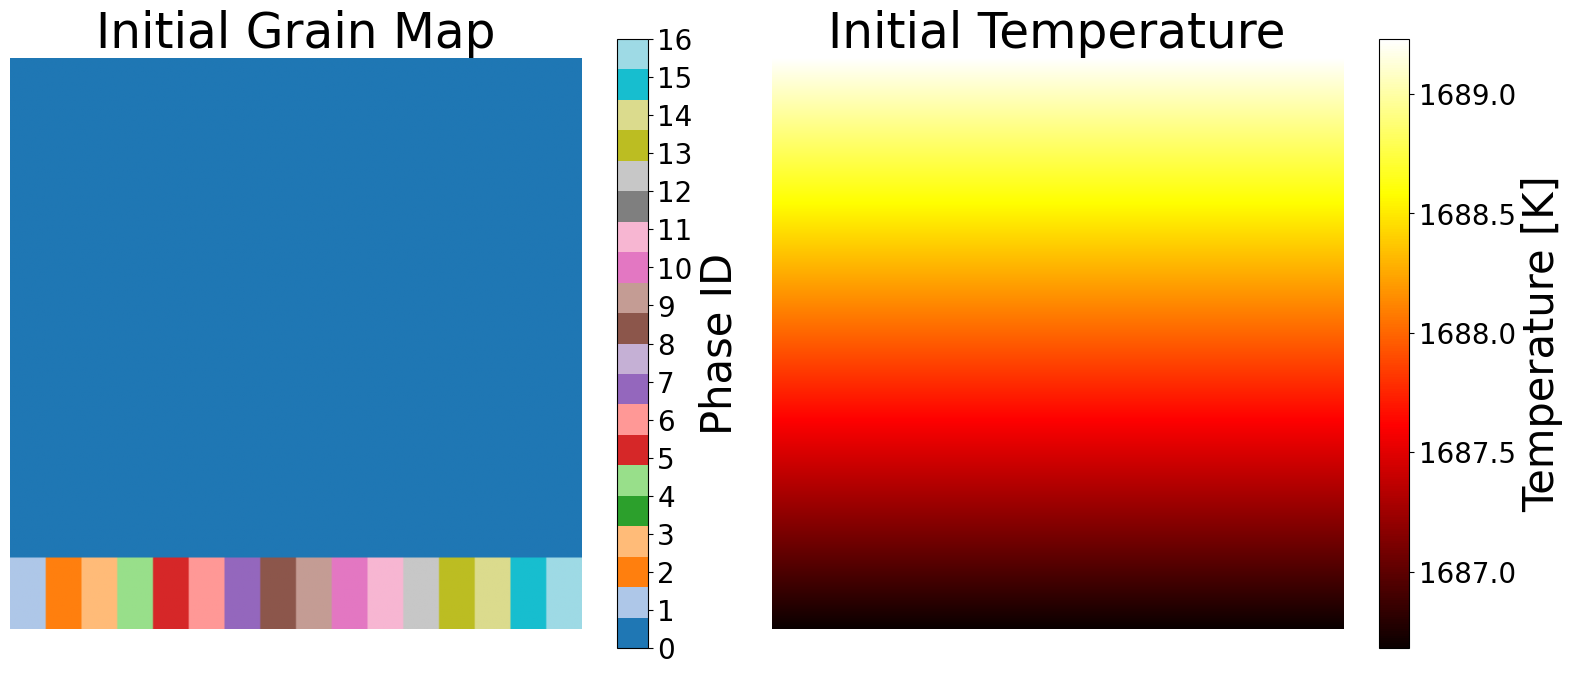

In [30]:
# =====================================================
# 4) Initialization
# =====================================================
phi_cpu = np.zeros((number_of_grain, nx, ny), dtype=np.float32)
seed_height = 32
factor = 2.2 / delta

n_solid = number_of_grain - 1
grain_width = nx // n_solid

for l in range(nx):
    grain_id = int(l // grain_width) + 1
    if grain_id > n_solid:
        grain_id = n_solid
    for m in range(ny):
        y = m * dy
        dist = y - (seed_height * dy)
        phi_solid = 0.5 * (1.0 - np.tanh(factor * dist))
        phi_cpu[grain_id, l, m] = phi_solid
        phi_cpu[0, l, m] = 1.0 - phi_solid

temp_cpu = np.zeros((nx, ny), dtype=np.float64)
for m in range(ny):
    temp_cpu[:, m] = T_melt   + G * (m - seed_height) * dy

# ===== Phase ID map =====
phase_map = np.argmax(phi_cpu, axis=0)

# ===== Figure =====
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
ax1, ax2 = axes

# ---- (1) Grain map ----
im1 = ax1.imshow(phase_map.T, cmap="tab20", origin="lower")
cbar1 = fig.colorbar(im1, ax=ax1, ticks=np.arange(number_of_grain), shrink=0.7)
cbar1.set_label("Phase ID", fontsize=30)
cbar1.ax.tick_params(labelsize=20)

ax1.set_title("Initial Grain Map", fontsize=35)
ax1.axis("off")

# ---- (2) Temperature ----
im2 = ax2.imshow(temp_cpu.T, cmap="hot", origin="lower")
cbar2 = fig.colorbar(im2, ax=ax2, shrink=0.7)
cbar2.set_label("Temperature [K]", fontsize=30)
cbar2.ax.tick_params(labelsize=20)

ax2.set_title("Initial Temperature", fontsize=35)
ax2.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "initial_grain_temp.png"), dpi=150)

In [31]:
# dtypeを統一（推奨）
phi_cpu  = phi_cpu.astype(np.float32)
temp_cpu = temp_cpu.astype(np.float32)
mf_cpu = mf.astype(np.int32)
nf_cpu = nf.astype(np.int32)
d_phi     = cuda.to_device(phi_cpu)
d_phi_new = cuda.to_device(phi_cpu)
d_temp    = cuda.to_device(temp_cpu)
d_mf      = cuda.to_device(mf_cpu)
d_nf      = cuda.to_device(nf_cpu)
d_wij     = cuda.to_device(wij.astype(np.float32))
d_aij     = cuda.to_device(aij.astype(np.float32))
d_mij     = cuda.to_device(mij.astype(np.float32))
d_n111    = cuda.to_device(grain_n111.astype(np.float32))

threadsperblock = (16, 16)
blockspergrid = (math.ceil(nx / threadsperblock[0]),
                 math.ceil(ny / threadsperblock[1]))

cooling_rate = np.float32(G * V_pulling * dt)  # 温度固定なら0でOK
T_melt_f  = np.float32(T_melt)
Sf_f  = np.float32(Sf)

In [32]:
# =====================================================
# 6) Main loop
# =====================================================
save_every = 5000
threshold_f = np.float32(1e-6)
g2_floor_f = np.float32((0.1/dx)**2)      
for nstep in range(1, nsteps + 1):
    kernel_update_temp[blockspergrid, threadsperblock](d_temp, cooling_rate, nx, ny)
    kernel_update_nfmf[blockspergrid, threadsperblock](d_phi,d_mf,d_nf,nx,ny,number_of_grain)
    kernel_update_phasefield_active[blockspergrid, threadsperblock](
        d_phi, d_phi_new, d_temp,d_mf,d_nf,
        d_wij, d_aij, d_mij,
        d_n111,
        nx, ny, number_of_grain, np.float32(dx), np.float32(dt),
        T_melt_f, Sf_f,
        np.float32(eps0_sl), np.float32(w0_sl),
        np.float32(a0), np.float32(delta_a), np.float32(mu_a), np.float32(p_round),
        g2_floor_f, np.float32(ksi), np.float32(omg)
    )


    d_phi, d_phi_new = d_phi_new, d_phi

    # if nstep % save_every == 0:
    #     current_phi  = d_phi.copy_to_host()
    #     phase_map = np.argmax(current_phi, axis=0)
    #     current_temp = d_temp.copy_to_host()
    #     print(f"Step {nstep} | Tmin={current_temp.min():.3f} Tmax={current_temp.max():.3f}")

    #     plt.figure(figsize=(15, 5))
    #     plt.subplot(1, 3, 1)
    #     plt.imshow(phase_map.T, cmap="tab20", origin="lower", interpolation="nearest")
    #     plt.colorbar(ticks=range(number_of_grain), label="Phase ID")
    #     plt.axis("off")
    #     plt.title(f"coolingrate = {V_pulling*G} K/s   step {nstep}")

    #     plt.subplot(1, 3, 2)
    #     plt.imshow(current_temp.T, cmap="hot", origin="lower")
    #     plt.colorbar(label="T [K]")
    #     plt.axis("off")
    #     plt.title(f"Temperature step {nstep}")

    #     plt.subplot(1, 3, 3)
    #     plt.imshow(current_phi[1].T, cmap="bwr", origin="lower", vmin=0, vmax=1)
    #     plt.colorbar()
    #     plt.axis("off")
    #     plt.title(f"phi(grain 1) step {nstep}")

    #     plt.tight_layout()
    #     plt.savefig(os.path.join(out_dir, f"step_{nstep}.png"), dpi=150)
    #     plt.close()
    if nstep % save_every == 0:
        # ===== Phase ID map =====
        current_phi  = d_phi.copy_to_host()
        phase_map = np.argmax(current_phi, axis=0)

        # ===== Figure =====
        fig, ax1 = plt.subplots(1, 1, figsize=(10, 10))

        # ---- (1) Grain map ----
        im1 = ax1.imshow(phase_map.T, cmap="tab20", origin="lower")
        cbar1 = fig.colorbar(im1, ax=ax1, ticks=np.arange(number_of_grain), shrink=0.7)
        cbar1.set_label("Phase ID",font="Times New Roman", fontsize=32)
        cbar1.ax.tick_params(labelsize=20)

        ax1.set_title(f"coolingrate = {V_pulling*G} K/s\nstep {nstep}",font="Times New Roman",fontsize=40)
        ax1.axis("off")

        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"step_{nstep}.png"), dpi=150)
        plt.close()
